**Connecting to Google Sheet**

In [ ]:
from google.colab import auth
import gspread
import pandas as pd
import numpy as np
from google.auth import default

# Authenticate user for Google Colab access to Google services
auth.authenticate_user()
# Get default credentials for Google services
creds, _ = default()
# Authorize gspread client with authenticated credentials
gc = gspread.authorize(creds)

# Google Sheet URL where the response data is stored
url = "https://docs.google.com/spreadsheets/d/1JA7x0sWtWTbbfOcYmzx8DbuCxip8tC7YKo3wIrS4F3Q/edit?usp=sharing"
# Open the spreadsheet by URL and select the first sheet
sheet = gc.open_by_url(url).sheet1

# Retrieve all records from the sheet and convert to a pandas DataFrame
data = sheet.get_all_records()
df   = pd.DataFrame(data)

# Check if the DataFrame is empty (no responses yet)
if df.empty:
    print("WARNING: No responses yet — using sample data for testing.")
    # If empty, populate with sample data for demonstration and testing purposes
    df = pd.DataFrame({
        "What is your email address?":                                                        ["test@gmail.com"],
        "Do you have PCOS? (control question)":                                               ["No"],
        "Are you currently on birth control?":                                                ["No"],
        "If yes, are you answering based on symptoms before birth control?":                  ["No"],
        "How often do you get your menstrual period?":                                        ["Irregularly"],
        "What is your average cycle length?":                                                 [">35 days"],
        "At what age did you start your period?":                                             [13],
        "Have your cycles always been irregular?":                                            ["Yes"],
        "Have you been diagnosed with infertility?":                                          ["No"],
        "Have you been diagnosed with polycystic ovaries?":                                   ["No"],
        "Do you have excess, dark, coarse hair growth on your face, chest, or abdomen?":      ["Moderate"],
        "Do you have dark skin patches on your neck or underarms?":                           ["Yes"],
        "How often do you experience persistent acne (if older than 18)?":                    ["Frequently"],
        "Have you experienced hair thinning or hair loss on your scalp?":                     ["Yes"],
        "Do you have a family history of PCOS?":                                              ["No"],
        "Do you currently have diabetes?":                                                    ["No"],
        "How old are you?":                                                                   [28],
        "Do you currently have hypertension?":                                                ["No"],
        "What is your Body Mass Index (BMI)":                                                 ["Less than 24.9"],
        "Do you have any unexplained weight gain?":                                           ["Yes"],
        "Do you have difficulty losing weight?":                                              ["Yes"],
        "Do you have energy crashes?":                                                        ["No"],
        "Do you have irregular heartbeat (arrhythmia)?":                                      ["No"],
        "Have you previously had high or low blood pressure?":                                ["High"],
        "What is your current blood pressure? (mmHg)":                                        ["Normal (<120/<80)"],
        "Have you previously had high or low blood sugar?":                                   ["No"],
        "What is your current blood sugar? (mg/dL)":                                          ["Normal (<100)"],
        "Have you previously had high or low cholesterol?":                                   ["No"],
        "What is your current cholesterol? (mg/dL)":                                          ["Normal (<200)"],
        "Total testosterone levels (ng/dL)":                                                  ["Normal (15-70)"],
        "Total free testosterone level (pg/mL)":                                              ["Normal (0.3-1.9)"],
        "Total free androgen index":                                                          ["Normal (<5)"],
        "Total androstenedione (ANSD) level (ng/dL)":                                         ["Normal (30-200)"],
        "Dehydroepiandrosterone sulfate (DHEAS) level (ug/dL)":                               ["Normal (35-430)"],
    })

# Print the number of responses loaded and the columns for verification
print(f"Responses loaded: {len(df)}")
print(df.columns.tolist())

Responses loaded: 18
['Timestamp', 'What is your email address?', 'Do you have PCOS? (control question)', 'How often do you get your menstrual period?', 'What is your average cycle length', 'At what age did you start your period?', 'Have your cycles always been irregular? (without use of supplemental hormones)', 'Have you been diagnosed with infertility?', 'Have you been diagnosed with polycystic ovaries?', 'Do you have excess, dark, coarse hair growth on your face, chest or abdomen?', 'Do you have dark skin patches on your neck or underarms?', 'How often do you experience persistent acne (if older than 18)?', 'Have you experienced hair thinning or hair loss on your scalp?', 'Do you have a family history of PCOS?', 'Do you currently have diabetes?', 'How old are you?', 'Do you currently have hypertension?', 'What is your Body Mass Index (BMI)?', 'Do you have any unexplained weight gain?', 'Do you have difficulty losing weight?', 'Do you have energy crashes?', 'Do you have irregular hea

**Column Mapping**

In [ ]:
COLUMN_MAP = {
    # Control Questions
    "email_address":          "What is your email address?",
    "pcos_control":           "Do you have PCOS? (control question)",

    # Birth Control Related Questions
    "on_birth_control":       "Are you currently on birth control?",
    "bc_historical":          "If yes, are you answering based on symptoms before birth control?",

    # Menstrual Cycle Questions
    "cycle_frequency":        "How often do you get your menstrual period?",
    "cycle_length":           "What is your average cycle length?",
    "menarche_age":           "At what age did you start your period?",
    "always_irregular":       "Have your cycles always been irregular?",
    "infertility":            "Have you been diagnosed with infertility?",

    # Hyperandrogenism Symptoms
    "diagnosed_pcos_ovaries": "Have you been diagnosed with polycystic ovaries?",
    "excess_hair":            "Do you have excess, dark, coarse hair growth on your face, chest, or abdomen?",
    "skin_darkening":         "Do you have dark skin patches on your neck or underarms?",
    "acne":                   "How often do you experience persistent acne (if older than 18)?",
    "hair_loss":              "Have you experienced hair thinning or hair loss on your scalp?",

    # Supporting Risk Factors and General Health
    "age":                    "How old are you?",
    "family_pcos":            "Do you have a family history of PCOS?",
    "has_diabetes":           "Do you currently have diabetes?",
    "has_hypertension":       "Do you currently have hypertension?",
    "bmi":                    "What is your Body Mass Index (BMI)",
    "weight_gain":            "Do you have any unexplained weight gain?",
    "difficulty_losing":      "Do you have difficulty losing weight?",
    "energy_crashes":         "Do you have energy crashes?",
    "irregular_heartbeat":    "Do you have irregular heartbeat (arrhythmia)?",

    # Blood Factors - Historical and Current
    "prev_blood_pressure":    "Have you previously had high or low blood pressure?",
    "current_blood_pressure": "What is your current blood pressure? (mmHg)",
    "prev_blood_sugar":       "Have you previously had high or low blood sugar?",
    "current_blood_sugar":    "What is your current blood sugar? (mg/dL)",
    "prev_cholesterol":       "Have you previously had high or low cholesterol?",
    "current_cholesterol":    "What is your current cholesterol? (mg/dL)",

    # Lab Test Results
    "total_testosterone":     "Total testosterone levels (ng/dL)",
    "free_testosterone":      "Total free testosterone level (pg/mL)",
    "free_androgen_index":    "Total free androgen index",
    "androstenedione":        "Total androstenedione (ANSD) level (ng/dL)",
    "dheas":                  "Dehydroepiandrosterone sulfate (DHEAS) level (ug/dL)",
}

# Create a reverse mapping for renaming DataFrame columns easily
reverse_map = {v: k for k, v in COLUMN_MAP.items()}
# Rename DataFrame columns using the reverse map for consistency
df_clean    = df.rename(columns=reverse_map)

# Identify and print any columns that were not matched in the mapping
unmatched = [c for c in df.columns if c not in reverse_map]
print("Columns mapped.")
print(f"Unmatched: {unmatched if unmatched else 'None — all matched!'}")
# Verify if the email address column is present after renaming
print(f"Email column: {'found' if 'email_address' in df_clean.columns else 'MISSING'}")

Columns mapped.
Unmatched: ['Timestamp', 'What is your average cycle length', 'Have your cycles always been irregular? (without use of supplemental hormones)', 'Do you have excess, dark, coarse hair growth on your face, chest or abdomen?', 'What is your Body Mass Index (BMI)?', 'What is your current cholesterol?  (mg/dL)', 'Total testosterone level (ng/dL)']
Email column: found


**Lab Refrence Ranges**

In [ ]:
LAB_RANGES = {
    "total_testosterone": {
        "normal_high":         70,
        "elevated_low":        70,
        "elevated_high":      150,
        "high_low":            150,
        "unit": "ng/dL",
        "note": "Normal: 15-70 | Elevated: 70-150 | High: >150"
    },
    "free_testosterone": {
        "normal_high":         1.9,
        "elevated_low":        2.0,
        "elevated_high":       4.0,
        "high_low":            4.0,
        "unit": "pg/mL",
        "note": "Normal: 0.3-1.9 | Elevated: 2.0-4.0 | High: >4.0"
    },
    "free_androgen_index": {
        "normal_high":         5.0,
        "elevated_low":        5.0,
        "elevated_high":       10.0,
        "high_low":            10.0,
        "unit": "%",
        "note": "Normal: <5% | Elevated: 5-10% | High: >10%"
    },
    "androstenedione": {
        "normal_high":         200,
        "elevated_low":        200,
        "elevated_high":       300, # Updated from 350
        "high_low":            300, # Updated from 350
        "unit": "ng/dL",
        "note": "Normal: <200 | Elevated: 200-300 | High: >300" # Updated note
    },
    "dheas": {
        "normal_high":         430, # Updated from 350
        "elevated_low":        430, # Updated from 350
        "elevated_high":       600, # Updated from 500
        "high_low":            600, # Updated from 500
        "unit": "ug/dL",
        "note": "Normal: <430 | Elevated: 430-600 | High: >600" # Updated note
    },
}

LAB_PROB_KEYS = {
    "total_testosterone":  {"normal":"total_testosterone_normal",  "mildly_high":"total_testosterone_elevated",  "high":"total_testosterone_high"},
    "free_testosterone":   {"normal":"free_testosterone_normal",   "mildly_high":"free_testosterone_elevated",   "high":"free_testosterone_high"},
    "free_androgen_index": {"normal":"free_androgen_index_normal", "mildly_high":"free_androgen_index_elevated", "high":"free_androgen_index_high"},
    "androstenedione":     {"normal":"androstenedione_normal",     "mildly_high":"androstenedione_elevated",     "high":"androstenedione_high"},
    "dheas":               {"normal":"dheas_normal",               "mildly_high":"dheas_elevated",               "high":"dheas_high"},
}

def parse_lab(value):
    # Helper function to parse lab values, extracting numerical data from strings
    try:
        cleaned = str(value).strip().lower()
        # Remove common units from the string to isolate the number
        for unit in ["ng/dl","pg/ml","ug/dl","ng/ml","miu/ml","nmol/l","%"]:
            cleaned = cleaned.replace(unit, "")
        return float(cleaned.strip())
    except:
        # Return None if parsing fails (e.g., non-numeric or unhandled format)
        return None

print("Lab ranges configured.")

Lab ranges configured.


**Probability Weights**

In [ ]:
PROB_WEIGHTS = {
    # Probability weights for different menstrual cycle indicators
    "cycle_regular":               0.10,
    "cycle_irregular":             0.80,
    "cycle_rarely":                0.85,
    "cycle_never":                 0.85,

    "cycle_length_less_21":        0.30,
    "cycle_length_21_35":          0.10,
    "cycle_long":                  0.80,
    "cycle_variable":              0.85,

    "menarche_age_less_12":        0.20,
    "menarche_age_12_15":          0.10,
    "menarche_late":               0.30,

    "always_irregular_yes":        0.50,
    "infertility":                 0.75,

    # Probability weights for polycystic ovaries diagnosis
    "polycystic_ovaries_yes":      0.75,

    # Probability weights for hyperandrogenism symptoms (hair, skin, acne, hair loss)
    "hair_none":                   0.10,
    "hair_mild":                   0.30,
    "hair_noticeable":             0.60,
    "hair_significant":            0.70,

    "skin_darkening_yes":          0.60,
    "skin_darkening_no":           0.40,

    "acne_never":                  0.10,
    "acne_occasional":             0.15,
    "acne_frequent":               0.25,

    "hair_loss_none":              0.10,
    "hair_loss_mild":              0.35,
    "hair_loss_significant":       0.65,

    # Probability weights for family history
    "family_pcos_yes":             0.50, # Retained as score_pcos doesn't differentiate granular family history
    "family_pcos_no":              0.10,

    # Probability weights for general risk factors
    "has_diabetes":                0.45,

    "bmi_normal":                  0.15,
    "bmi_overweight":              0.35,
    "bmi_obese":                   0.55,

    "weight_gain":                 0.50,

    "difficulty_losing":           0.50,

    "energy_crashes_none":         0.15,
    "energy_crashes_occasional":   0.30,
    "energy_crashes_frequent":     0.50,

    "irregular_heartbeat_yes":     0.056,
    "has_hypertension":            0.129, # Added based on user input

    # Probability weights for metabolic indicators (previous conditions)
    "prev_blood_pressure_no":      0.10,
    "prev_low_bp":                 0.20,
    "prev_high_bp":                0.40,

    "prev_blood_sugar_no":         0.10,
    "prev_low_sugar":              0.25,
    "prev_high_sugar":             0.50,

    "prev_cholesterol_no":         0.15,
    "prev_low_chol":               0.25,
    "prev_high_chol":              0.45,

    # Probability weights for metabolic indicators (current conditions)
    "current_blood_pressure_normal":   0.10,
    "current_blood_pressure_elevated": 0.25,
    "current_blood_pressure_high":     0.45, # Renamed for clarity from current_high_bp

    "blood_sugar_normal":              0.15,
    "blood_sugar_pre":                 0.40,
    "blood_sugar_high":                0.60,

    "chol_normal":                     0.15,
    "chol_borderline":                 0.30,
    "chol_high":                       0.50,

    # Probability weights for lab test results (normal, elevated, high)
    "total_testosterone_normal":       0.15,
    "total_testosterone_elevated":     0.50,
    "total_testosterone_high":         0.70,

    "free_testosterone_normal":        0.15,
    "free_testosterone_elevated":      0.65,
    "free_testosterone_high":          0.85,

    "free_androgen_index_normal":      0.15,
    "free_androgen_index_elevated":    0.55,
    "free_androgen_index_high":        0.75,

    "androstenedione_normal":          0.15,
    "androstenedione_elevated":        0.65,
    "androstenedione_high":            0.85,

    "dheas_normal":                    0.05,
    "dheas_elevated":                  0.20,
    "dheas_high":                      0.35,
}

def log_odds(p):
    # Calculate log-odds from a given probability p
    p = max(0.001, min(0.999, p)) # Clip p to avoid log(0) or log(1)
    return np.log(p / (1 - p))

def sigmoid(lo):
    # Convert log-odds back to a probability using the sigmoid function
    return 1 / (1 + np.exp(-lo))

print("Probability weights loaded.")

Probability weights loaded.


**Scoring Engine**

In [ ]:
def score_pcos(row):
    """
    Total log-odds = Sum log(Pi / (1-Pi))
    P_final        = 1 / (1 + e^-(Total log-odds))
    """
    total_lo        = 0.0
    contributions   = []
    menstrual_flags = []
    ovary_flags     = []
    andro_flags     = []
    family_flags    = []
    risk_flags      = []
    metabolic_flags = []
    lab_flags       = []
    domains_hit     = set()

    def yes(key):
        return str(row.get(key,"")).strip().lower() in {
            "yes","y","true","1","always","often"
        }
    def norm(key):
        return str(row.get(key,"")).strip().lower()
    def get_num(key):
        try:    return float(str(row.get(key,"")).strip())
        except: return None

    def add(wk, fl, text, domain=None):
        nonlocal total_lo
        if wk not in PROB_WEIGHTS:
          return
        p  = PROB_WEIGHTS[wk]
        lo = log_odds(p)
        total_lo += lo
        contributions.append({
            "feature":       wk,
            "P_i":           p,
            "log(Pi/1-Pi)":  round(lo, 4),
            "running_total": round(total_lo, 4),
        })
        fl.append(f"{text}  [P={p} | log(P/1-P)={lo:.3f}]")
        if domain:
            domains_hit.add(domain)

    # Birth control
    on_bc = yes("on_birth_control")
    if on_bc and yes("bc_historical"):
        bc_note = "Using pre-birth-control symptoms"
    elif on_bc:
        bc_note = "On birth control — hormonal scores may be suppressed"
    else:
        bc_note = ""

    # SECTION 1: MENSTRUAL
    cf = norm("cycle_frequency")
    if "never" in cf:
        add("cycle_never",        menstrual_flags, "Amenorrhea",                  "menstrual")
    elif "rarely" in cf:
        add("cycle_rarely",       menstrual_flags, "Rarely gets period",           "menstrual")
    elif "irregular" in cf or "missing" in cf:
        add("cycle_irregular",    menstrual_flags, "Irregular cycles",             "menstrual")
    elif "regular" in cf:
        add("cycle_regular",      menstrual_flags, "Regular cycles")

    cl = norm("cycle_length")
    if ">35" in cl or ("35" in cl and "21-35" not in cl):
        add("cycle_long",         menstrual_flags, "Long cycles >35 days",         "menstrual")
    elif "<21" in cl:
        add("cycle_length_less_21", menstrual_flags, "Short cycles <21 days")
    elif "varies" in cl:
        add("cycle_variable",     menstrual_flags, "Variable cycles",              "menstrual")
    elif "21-35" in cl:
        add("cycle_length_21_35", menstrual_flags, "Normal cycle length 21-35 days")

    menarche = get_num("menarche_age")
    if menarche:
        if menarche < 12:
            add("menarche_age_less_12", menstrual_flags, f"Early menarche age {int(menarche)}")
        elif menarche <= 15:
            add("menarche_age_12_15",   menstrual_flags, f"Menarche age {int(menarche)}")
        else:
            add("menarche_late",        menstrual_flags, f"Late menarche age {int(menarche)}")

    ppy = get_num("periods_per_year")
    if ppy is not None and ppy <= 8:
        add("low_periods_year",   menstrual_flags, f"Only {int(ppy)} periods/year","menstrual")

    if yes("always_irregular"):
        add("always_irregular",   menstrual_flags, "Always been irregular",        "menstrual")

    if yes("infertility"):
        add("infertility",        menstrual_flags, "Diagnosed with infertility")

    # SECTION 2: POLYCYSTIC OVARIES
    if yes("diagnosed_pcos_ovaries"):
        add("polycystic_ovaries_yes", ovary_flags,
            "Diagnosed with polycystic ovaries", "polycystic_ovaries")

    # SECTION 3: HYPERANDROGENISM
    hair = norm("excess_hair")
    if "significant" in hair:
        add("hair_significant", andro_flags, "Significant hirsutism",          "hyperandrogenism")
    elif "moderate" in hair or "noticeable" in hair:
        add("hair_noticeable",  andro_flags, "Moderate/noticeable hirsutism",  "hyperandrogenism")
    elif "mild" in hair:
        add("hair_mild",        andro_flags, "Mild hirsutism")
    else:
        add("hair_none",        andro_flags, "No excess hair")


    if yes("skin_darkening"):
        add("skin_darkening_yes", andro_flags, "Acanthosis nigricans")
    else:
        add("skin_darkening_no",  andro_flags, "No skin darkening")

    acne = norm("acne")
    if "frequently" in acne:
        add("acne_frequent",   andro_flags, "Frequent persistent acne", "hyperandrogenism")
    elif "occasionally" in acne:
        add("acne_occasional", andro_flags, "Occasional acne")
    else:
        add("acne_never",      andro_flags, "No acne")

    hair_loss_val = norm("hair_loss")
    if "significant" in hair_loss_val or yes("hair_loss"):
        add("hair_loss_significant", andro_flags, "Significant hair loss", "hyperandrogenism")
    elif "mild" in hair_loss_val:
        add("hair_loss_mild",        andro_flags, "Mild hair loss")
    else:
        add("hair_loss_none",        andro_flags, "No hair loss")


    # SECTION 4: FAMILY HISTORY
    if yes("family_pcos"):
        add("family_pcos_yes", family_flags, "Family history of PCOS")
    else:
        add("family_pcos_no",  family_flags, "No family history of PCOS")

    # SECTION 5: RISK FACTORS
    if yes("has_diabetes"):
        add("has_diabetes", risk_flags, "Currently has diabetes  [P=0.45]")

    bmi_r = norm("bmi")
    bmi_n = get_num("bmi")
    if "obese" in bmi_r or (bmi_n and bmi_n >= 30):
        add("bmi_obese",      risk_flags, "BMI Obese  [P=0.55]")
    elif "overweight" in bmi_r or (bmi_n and 25 <= bmi_n < 30):
        add("bmi_overweight", risk_flags, "BMI Overweight  [P=0.35]")
    else:
        add("bmi_normal",     risk_flags, "BMI Normal  [P=0.15]")

    if yes("weight_gain"):
        add("weight_gain",       risk_flags, "Unexplained weight gain  [P=0.50]")
    if yes("difficulty_losing"):
        add("difficulty_losing", risk_flags, "Difficulty losing weight  [P=0.50]")

    ec = norm("energy_crashes")
    if "frequently" in ec or yes("energy_crashes"):
        add("energy_crashes_frequent",   risk_flags, "Frequent energy crashes")
    elif "occasionally" in ec:
        add("energy_crashes_occasional", risk_flags, "Occasional energy crashes")
    else:
        add("energy_crashes_none",       risk_flags, "No energy crashes")

    if yes("irregular_heartbeat"):
        add("irregular_heartbeat_yes", risk_flags, "Irregular heartbeat  [P=0.056]")

    # SECTION 6: METABOLIC
    for pk, hk, lk, nk, label in [
        ("prev_blood_pressure","prev_high_bp",   "prev_low_bp",   "prev_blood_pressure_no","blood pressure"),
        ("prev_blood_sugar",   "prev_high_sugar","prev_low_sugar", "prev_blood_sugar_no",   "blood sugar"),
        ("prev_cholesterol",   "prev_high_chol", "prev_low_chol",  "prev_cholesterol_no",   "cholesterol"),
    ]:
        pv = norm(pk)
        if "high" in pv:
            add(hk, metabolic_flags, f"Previous high {label}")
        elif "low" in pv:
            add(lk, metabolic_flags, f"Previous low {label}")
        else:
            add(nk, metabolic_flags, f"No previous {label} issues")

    bp_r = norm("current_blood_pressure")
    bp_n = get_num("current_blood_pressure")
    if (bp_n and bp_n > 130) or "high" in bp_r:
        add("current_high_bp",                 metabolic_flags, "Current blood pressure elevated")
    elif bp_n and 120 <= bp_n <= 130:
        add("current_blood_pressure_elevated", metabolic_flags, "Current blood pressure borderline")
    else:
        add("current_blood_pressure_normal",   metabolic_flags, "Current blood pressure normal")

    bs_r = norm("current_blood_sugar")
    bs_n = get_num("current_blood_sugar")
    if "high" in bs_r or (bs_n and bs_n > 125):
        add("blood_sugar_high",   metabolic_flags, "Current blood sugar high")
    elif "prediabetic" in bs_r or (bs_n and 100 <= bs_n <= 125):
        add("blood_sugar_pre",    metabolic_flags, "Current blood sugar prediabetic")
    else:
        add("blood_sugar_normal", metabolic_flags, "Current blood sugar normal")

    ch_r = norm("current_cholesterol")
    ch_n = get_num("current_cholesterol")
    if "high" in ch_r or (ch_n and ch_n > 239):
        add("chol_high",          metabolic_flags, "Current cholesterol high")
    elif "borderline" in ch_r or (ch_n and 200 <= ch_n <= 239):
        add("chol_borderline",    metabolic_flags, "Current cholesterol borderline")
    else:
        add("chol_normal",        metabolic_flags, "Current cholesterol normal")

    # SECTION 7: LABS
    labs_submitted = 0
    for lab_key, prob_keys_map in LAB_PROB_KEYS.items():
        raw_val = str(row.get(lab_key, "")).strip().lower()

        # Check if the raw value contains a descriptive keyword
        if "normal" in raw_val:
            add(prob_keys_map["normal"], lab_flags,
                f"{lab_key}: {raw_val} (Normal)", None) # No domain for normal
            labs_submitted += 1
        elif "elevated" in raw_val:
            add(prob_keys_map["mildly_high"], lab_flags,
                f"{lab_key}: {raw_val} (Elevated)", "hyperandrogenism")
            labs_submitted += 1
        elif "high" in raw_val:
            add(prob_keys_map["high"], lab_flags,
                f"{lab_key}: {raw_val} (High)", "hyperandrogenism")
            labs_submitted += 1
        else: # No descriptive keyword, try to parse as a number
            val = parse_lab(raw_val)
            if val is not None:
                labs_submitted += 1
                ref = LAB_RANGES[lab_key]

                # Generic logic for all labs (including total_testosterone)
                if val >= ref["high_low"]:
                    add(prob_keys_map["high"],        lab_flags,
                        f"{lab_key}: {val} {ref['unit']} HIGH ({ref['note']})",
                        "hyperandrogenism")
                elif val >= ref["elevated_low"]:
                    add(prob_keys_map["mildly_high"], lab_flags,
                        f"{lab_key}: {val} {ref['unit']} ELEVATED ({ref['note']})",
                        "hyperandrogenism")
                else: # Must be normal if not high or elevated
                    add(prob_keys_map["normal"],      lab_flags,
                        f"{lab_key}: {val} {ref['unit']} NORMAL ({ref['note']})")

    # FINAL CALCULATION
    p_final = sigmoid(total_lo)
    p_pct   = round(p_final * 100, 1)

    rotterdam = domains_hit.intersection(
        {"menstrual","hyperandrogenism","polycystic_ovaries"}
    )
    r_count = len(rotterdam)
    r_note  = (f"{r_count}/3 Rotterdam domains: "
               f"{', '.join(rotterdam) if rotterdam else 'none'}")

    if r_count >= 2 or p_pct >= 70:
        risk   = "HIGH — Strong PCOS indicators"
        advice = ("Multiple PCOS criteria met. Please consult a gynecologist or "
                  "endocrinologist for: pelvic ultrasound, full androgen panel, "
                  "glucose tolerance test, fasting insulin.")
    elif r_count == 1 or p_pct >= 45:
        risk   = "MODERATE — Several indicators present"
        advice = ("Notable indicators present. Consider discussing with your "
                  "OB-GYN. Ultrasound and hormonal labs may be warranted.")
    elif p_pct >= 25:
        risk   = "LOW-MODERATE — Some indicators"
        advice = ("A few indicators present. Monitor symptoms and maintain "
                  "a healthy lifestyle. See a doctor if symptoms worsen.")
    else:
        risk   = "LOW — Minimal indicators"
        advice = "No strong indicators at this time. Continue routine care."

    return pd.Series({
        "total_log_odds":     round(total_lo, 4),
        "P_final":            round(p_final, 4),
        "P_final_pct":        p_pct,
        "features_triggered": len(contributions),
        "labs_submitted":     labs_submitted,
        "rotterdam_count":    r_count,
        "rotterdam_note":     r_note,
        "risk_level":         risk,
        "bc_note":            bc_note,
        "menstrual_flags":    " | ".join(menstrual_flags) or "None",
        "ovary_flags":        " | ".join(ovary_flags)     or "None",
        "androgenic_flags":   " | ".join(andro_flags)     or "None",
        "family_flags":       " | ".join(family_flags)    or "None",
        "risk_flags":         " | ".join(risk_flags)      or "None",
        "metabolic_flags":    " | ".join(metabolic_flags) or "None",
        "lab_flags":          " | ".join(lab_flags)       or "No labs",
        "recommendation":     advice,
        "contributions":      contributions,
    })

In [ ]:
# Apply the scoring function to each row of the cleaned DataFrame
results = df_clean.apply(score_pcos, axis=1)

# Concatenate the original cleaned DataFrame with the new scoring results
df_results = pd.concat(
    [df_clean.reset_index(drop=True),
     results.reset_index(drop=True)],
    axis=1
)

print(f"Scoring complete for {len(df_results)} responses.")
print(f"Model: Total log-odds = Sum log(Pi/1-Pi) -> P_final = sigmoid(total)")

Scoring complete for 18 responses.
Model: Total log-odds = Sum log(Pi/1-Pi) -> P_final = sigmoid(total)


**Print Results**

In [ ]:
for i, row in df_results.iterrows():
    print(f"\nRESPONSE #{i+1}  |  Age: {row.get('age','N/A')}  |  BMI: {row.get('bmi','N/A')}")
    print(f"  Total log-odds :  {row['total_log_odds']}")
    print(f"  P(PCOS)        :  {row['P_final']}  ({row['P_final_pct']}%)")
    print(f"  Risk           :  {row['risk_level']}")
    print(f"  Rotterdam      :  {row['rotterdam_note']}")
    if row['bc_note']:
        print(f"  Birth control  :  {row['bc_note']}")
    print(f"\n  Menstrual      :  {row['menstrual_flags']}")
    print(f"  Ovaries        :  {row['ovary_flags']}")
    print(f"  Androgens      :  {row['androgenic_flags']}")
    print(f"  Family Hx      :  {row['family_flags']}")
    print(f"  Risk factors   :  {row['risk_flags']}")
    print(f"  Metabolic      :  {row['metabolic_flags']}")
    print(f"  Labs           :  {row['lab_flags']}")
    print(f"\n  Recommendation :  {row['recommendation']}")
    print(f"\n  Log-odds breakdown:")
    print(f"  {'Feature':<35} {'P_i':>5}  {'log(P/1-P)':>10}")
    print(f"  {'-'*53}")
    for c in row['contributions']:
        print(f"  {c['feature']:<35} {c['P_i']:>5}  {c['log(Pi/1-Pi)']:>10.4f}")
    print(f"  {'-'*53}")
    print(f"  {'TOTAL':<35} {'':>5}  {row['total_log_odds']:>10.4f}")
    print(f"  {'P_final = sigmoid(total)':<35} {'':>5}  {row['P_final']:>10.4f}")
    print()



RESPONSE #1  |  Age: 21  |  BMI: N/A
  Total log-odds :  -21.5587
  P(PCOS)        :  0.0  (0.0%)
  Risk           :  HIGH — Strong PCOS indicators
  Rotterdam      :  3/3 Rotterdam domains: polycystic_ovaries, menstrual, hyperandrogenism

  Menstrual      :  Irregular cycles  [P=0.8 | log(P/1-P)=1.386]
  Ovaries        :  Diagnosed with polycystic ovaries  [P=0.75 | log(P/1-P)=1.099]
  Androgens      :  No excess hair  [P=0.1 | log(P/1-P)=-2.197] | Acanthosis nigricans  [P=0.6 | log(P/1-P)=0.405] | Occasional acne  [P=0.15 | log(P/1-P)=-1.735] | Mild hair loss  [P=0.35 | log(P/1-P)=-0.619]
  Family Hx      :  No family history of PCOS  [P=0.1 | log(P/1-P)=-2.197]
  Risk factors   :  Currently has diabetes  [P=0.45]  [P=0.45 | log(P/1-P)=-0.201] | BMI Normal  [P=0.15]  [P=0.15 | log(P/1-P)=-1.735] | No energy crashes  [P=0.15 | log(P/1-P)=-1.735] | Irregular heartbeat  [P=0.056]  [P=0.056 | log(P/1-P)=-2.825]
  Metabolic      :  Previous high blood pressure  [P=0.4 | log(P/1-P)=-0.405

**Dashboard Charts**

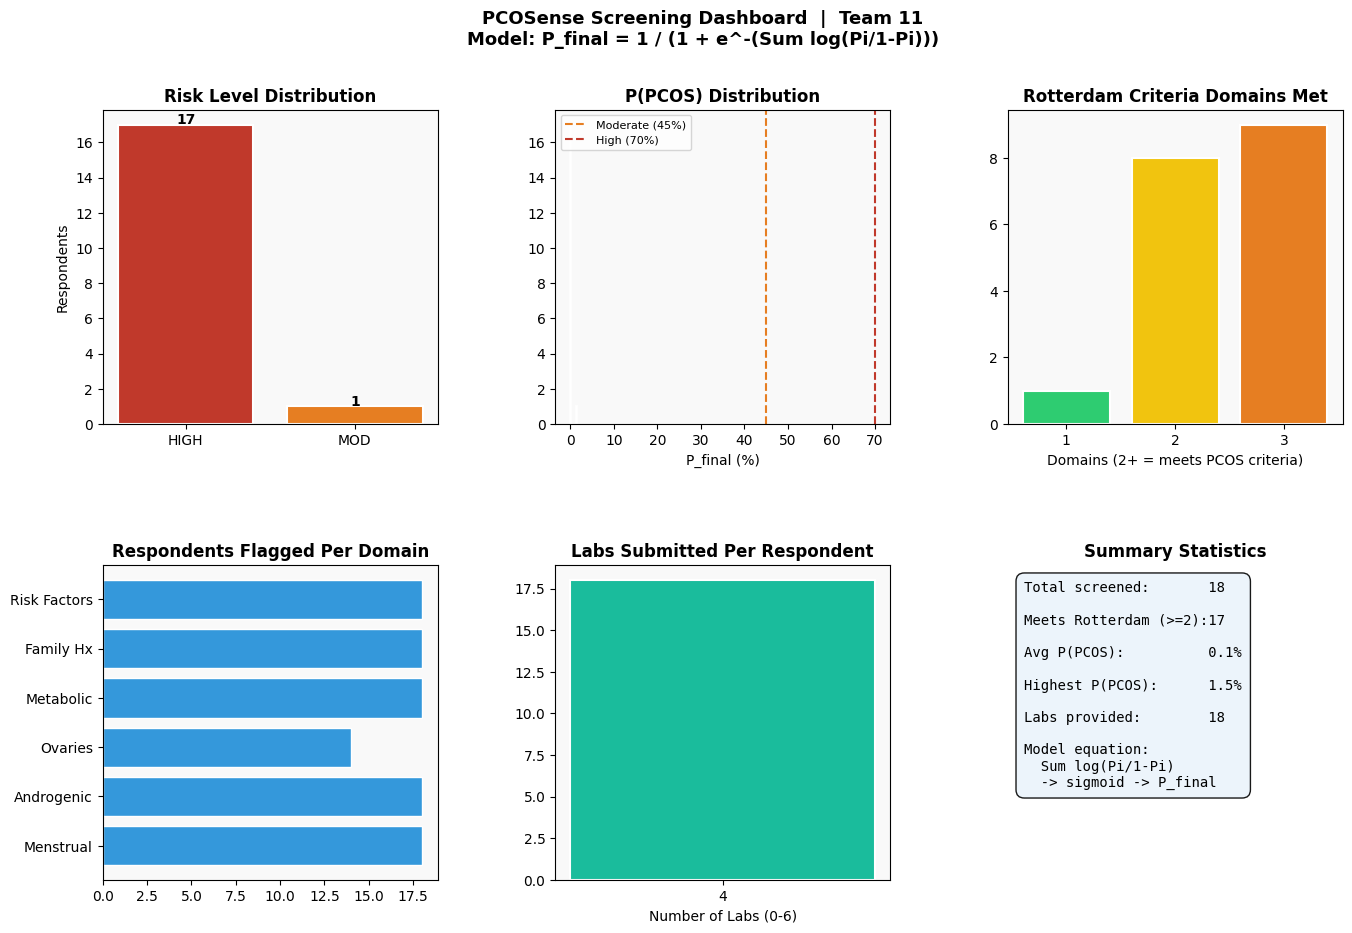

Dashboard saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    "PCOSense Screening Dashboard  |  Team 11\n"
    "Model: P_final = 1 / (1 + e^-(Sum log(Pi/1-Pi)))",
    fontsize=13, fontweight="bold"
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

color_map = {
    "HIGH — Strong PCOS indicators":         "#c0392b",
    "MODERATE — Several indicators present": "#e67e22",
    "LOW-MODERATE — Some indicators":        "#f1c40f",
    "LOW — Minimal indicators":              "#2ecc71",
}

# Plot 1: Risk distribution
ax1 = fig.add_subplot(gs[0, 0])
rc  = df_results["risk_level"].value_counts()
bc  = [color_map.get(r, "#95a5a6") for r in rc.index]
ax1.bar(["HIGH","MOD","LOW-M","LOW"][:len(rc)], rc.values,
        color=bc, edgecolor="white", linewidth=1.5)
ax1.set_title("Risk Level Distribution", fontweight="bold")
ax1.set_ylabel("Respondents")
ax1.set_facecolor("#f9f9f9")
for j, v in enumerate(rc.values):
    ax1.text(j, v + 0.05, str(v), ha="center", fontweight="bold")

# Plot 2: P(PCOS) histogram
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df_results["P_final_pct"], bins=12,
         color="#8e44ad", edgecolor="white", linewidth=1.2)
ax2.axvline(45, color="#e67e22", linestyle="--", lw=1.5, label="Moderate (45%)")
ax2.axvline(70, color="#c0392b", linestyle="--", lw=1.5, label="High (70%)")
ax2.set_title("P(PCOS) Distribution", fontweight="bold")
ax2.set_xlabel("P_final (%)")
ax2.legend(fontsize=8)
ax2.set_facecolor("#f9f9f9")

# Plot 3: Rotterdam domains
ax3 = fig.add_subplot(gs[0, 2])
rd  = df_results["rotterdam_count"].value_counts().sort_index()
ax3.bar(rd.index.astype(str), rd.values,
        color=["#2ecc71","#f1c40f","#e67e22","#c0392b"][:len(rd)],
        edgecolor="white", linewidth=1.5)
ax3.set_title("Rotterdam Criteria Domains Met", fontweight="bold")
ax3.set_xlabel("Domains (2+ = meets PCOS criteria)")
ax3.set_facecolor("#f9f9f9")

# Plot 4: Flags per domain
ax4 = fig.add_subplot(gs[1, 0])
domain_cols = {
    "Menstrual":    "menstrual_flags",
    "Androgenic":   "androgenic_flags",
    "Ovaries":      "ovary_flags",
    "Metabolic":    "metabolic_flags",
    "Family Hx":    "family_flags",
    "Risk Factors": "risk_flags",
}
domain_hits = {
    k: (df_results[v] != "None").sum()
    for k, v in domain_cols.items()
}
ax4.barh(list(domain_hits.keys()), list(domain_hits.values()),
         color="#3498db", edgecolor="white")
ax4.set_title("Respondents Flagged Per Domain", fontweight="bold")
ax4.set_facecolor("#f9f9f9")

# Plot 5: Labs submitted
ax5 = fig.add_subplot(gs[1, 1])
lc  = df_results["labs_submitted"].value_counts().sort_index()
ax5.bar(lc.index.astype(str), lc.values,
        color="#1abc9c", edgecolor="white", linewidth=1.5)
ax5.set_title("Labs Submitted Per Respondent", fontweight="bold")
ax5.set_xlabel("Number of Labs (0-6)")
ax5.set_facecolor("#f9f9f9")

# Plot 6: Summary stats
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
stats = (
    f"Total screened:       {len(df_results)}\n\n"
    f"Meets Rotterdam (>=2):{(df_results['rotterdam_count']>=2).sum()}\n\n"
    f"Avg P(PCOS):          {df_results['P_final_pct'].mean():.1f}%\n\n"
    f"Highest P(PCOS):      {df_results['P_final_pct'].max():.1f}%\n\n"
    f"Labs provided:        {(df_results['labs_submitted']>0).sum()}\n\n"
    f"Model equation:\n"
    f"  Sum log(Pi/1-Pi)\n"
    f"  -> sigmoid -> P_final"
)
ax6.text(0.05, 0.95, stats, transform=ax6.transAxes,
         fontsize=10, verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.6", facecolor="#eaf3fb", alpha=0.9))
ax6.set_title("Summary Statistics", fontweight="bold")

plt.savefig("pcos_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved.")


**Generate PDF Report**

In [ ]:
!pip install reportlab -q

import os
from reportlab.lib.pagesizes import letter
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer,
    Table, TableStyle, HRFlowable
)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
from reportlab.lib.units import inch
from reportlab.lib.enums import TA_CENTER, TA_LEFT

NAVY      = colors.HexColor("#1B3A6B")
BLUE      = colors.HexColor("#2D6EA8")
LIGHTBLUE = colors.HexColor("#D6E8F7")
RED       = colors.HexColor("#C0392B")
GOLD      = colors.HexColor("#D4A017")
LIGHTGOLD = colors.HexColor("#FDF6E3")
OFFWHITE  = colors.HexColor("#F4F8FC")
GRAY      = colors.HexColor("#555566")

base = getSampleStyleSheet()

def PS(name, **kw):
    return ParagraphStyle(name, parent=base["Normal"], **kw)

ST = {
    "title":   PS("t",  fontSize=20, textColor=NAVY,
                   fontName="Helvetica-Bold", alignment=TA_CENTER, spaceAfter=4),
    "sub":     PS("s",  fontSize=11, textColor=BLUE,
                   fontName="Helvetica", alignment=TA_CENTER, spaceAfter=8),
    "h2":      PS("h2", fontSize=11, textColor=NAVY,
                   fontName="Helvetica-Bold", spaceBefore=8, spaceAfter=3),
    "body":    PS("b",  fontSize=9,  textColor=colors.HexColor("#1C1C2E"),
                   fontName="Helvetica", leading=13, spaceAfter=3),
    "small":   PS("sm", fontSize=8,  textColor=GRAY,
                   fontName="Helvetica-Oblique", alignment=TA_CENTER),
}

def make_pcos_pdf(row, filename):
    """Generate a personal PDF report for one respondent."""
    doc = SimpleDocTemplate(
        filename, pagesize=letter,
        leftMargin=0.75*inch, rightMargin=0.75*inch,
        topMargin=0.75*inch,  bottomMargin=0.75*inch,
    )
    story = []

    # Header banner
    banner_data = [[
        Paragraph("PCOSense Screening Results", ST["title"]),
        Paragraph("Team 11", ST["sub"]),
    ]]
    banner = Table(banner_data, colWidths=[7.0*inch])
    banner.setStyle(TableStyle([
        ("BACKGROUND",    (0,0), (-1,-1), NAVY),
        ("TOPPADDING",    (0,0), (-1,-1), 14),
        ("BOTTOMPADDING", (0,0), (-1,-1), 14),
        ("LEFTPADDING",   (0,0), (-1,-1), 16),
    ]))
    story.append(banner)
    story.append(Spacer(1, 10))

    # Risk box
    risk     = row.get("risk_level",     "N/A")
    p_pct    = row.get("P_final_pct",    "N/A")
    total_lo = row.get("total_log_odds", "N/A")
    rotterdam= row.get("rotterdam_note", "N/A")
    bc       = row.get("bc_note",        "")

    risk_color = colors.HexColor("#FDECEA")
    if "MODERATE" in risk and "LOW" not in risk:
        risk_color = colors.HexColor("#FEF3E2")
    elif "LOW-MODERATE" in risk:
        risk_color = colors.HexColor("#FEFCE8")
    elif "LOW" in risk and "HIGH" not in risk:
        risk_color = colors.HexColor("#EAFAF1")

    risk_content = [
        [Paragraph(f"<b>Risk Level:</b>  {risk}", ST["h2"])],
        [Paragraph(f"<b>P(PCOS):</b>  {p_pct}%   |   "
                   f"<b>Total log-odds:</b>  {total_lo}", ST["body"])],
        [Paragraph(f"<b>Rotterdam:</b>  {rotterdam}", ST["body"])],
    ]
    if bc:
        risk_content.append([Paragraph(f"<b>Birth Control Note:</b>  {bc}", ST["body"])])

    risk_table = Table(risk_content, colWidths=[7.0*inch])
    risk_table.setStyle(TableStyle([
        ("BACKGROUND",    (0,0), (-1,-1), risk_color),
        ("BOX",           (0,0), (-1,-1), 1, BLUE),
        ("TOPPADDING",    (0,0), (-1,-1), 6),
        ("BOTTOMPADDING", (0,0), (-1,-1), 6),
        ("LEFTPADDING",   (0,0), (-1,-1), 12),
        ("RIGHTPADDING",  (0,0), (-1,-1), 12),
    ]))
    story.append(risk_table)
    story.append(Spacer(1, 8))

    # Flags section
    story.append(Paragraph("Flags Detected", ST["h2"]))

    flag_data = [
        ["Menstrual",   row.get("menstrual_flags",  "None")],
        ["Ovaries",     row.get("ovary_flags",       "None")],
        ["Androgens",   row.get("androgenic_flags",  "None")],
        ["Family Hx",   row.get("family_flags",      "None")],
        ["Risk Factors",row.get("risk_flags",        "None")],
        ["Metabolic",   row.get("metabolic_flags",   "None")],
        ["Labs",        row.get("lab_flags",         "No labs provided")],
    ]
    flag_rows = [[
        Paragraph(f"<b>{r[0]}</b>", ST["body"]),
        Paragraph(str(r[1]),        ST["body"]),
    ] for r in flag_data]

    flag_table = Table(flag_rows, colWidths=[1.1*inch, 5.9*inch])
    flag_table.setStyle(TableStyle([
        ("GRID",          (0,0), (-1,-1), 0.4, colors.HexColor("#C0D4E8")),
        ("ROWBACKGROUNDS",(0,0), (-1,-1), [colors.white, OFFWHITE]),
        ("TOPPADDING",    (0,0), (-1,-1), 4),
        ("BOTTOMPADDING", (0,0), (-1,-1), 4),
        ("LEFTPADDING",   (0,0), (-1,-1), 8),
        ("RIGHTPADDING",  (0,0), (-1,-1), 8),
        ("VALIGN",        (0,0), (-1,-1), "TOP"),
    ]))
    story.append(flag_table)
    story.append(Spacer(1, 8))

    # Recommendation box
    advice_data = [[
        Paragraph("<b>Recommendation</b>", ST["h2"]),
        Paragraph(row.get("recommendation",""), ST["body"]),
    ]]
    advice_table = Table(advice_data, colWidths=[7.0*inch])
    advice_table.setStyle(TableStyle([
        ("BACKGROUND",    (0,0), (-1,-1), LIGHTGOLD),
        ("BOX",           (0,0), (-1,-1), 1, GOLD),
        ("TOPPADDING",    (0,0), (-1,-1), 8),
        ("BOTTOMPADDING", (0,0), (-1,-1), 8),
        ("LEFTPADDING",   (0,0), (-1,-1), 12),
        ("RIGHTPADDING",  (0,0), (-1,-1), 12),
        ("VALIGN",        (0,0), (-1,-1), "TOP"),
    ]))
    story.append(advice_table)
    story.append(Spacer(1, 8))

    # Log-odds audit trail
    story.append(Paragraph("Log-Odds Audit Trail", ST["h2"]))
    audit_header = [[
        Paragraph("<b>Feature</b>",         ST["body"]),
        Paragraph("<b>P(i)</b>",            ST["body"]),
        Paragraph("<b>log(Pi/1-Pi)</b>",    ST["body"]),
        Paragraph("<b>Running Total</b>",   ST["body"]),
    ]]
    audit_rows = []
    for c in row.get("contributions", []):
        audit_rows.append([
            Paragraph(str(c["feature"]),         ST["body"]),
            Paragraph(str(c["P_i"]),             ST["body"]),
            Paragraph(f"{c['log(Pi/1-Pi)']:.4f}",ST["body"]),
            Paragraph(f"{c['running_total']:.4f}",ST["body"]),
        ])
    # Totals row
    audit_rows.append([
        Paragraph("<b>TOTAL</b>",            ST["body"]),
        Paragraph("",                        ST["body"]),
        Paragraph(f"<b>{total_lo}</b>",      ST["body"]),
        Paragraph(f"<b>P_final = {p_pct}%</b>", ST["body"]),
    ])

    audit_table = Table(
        audit_header + audit_rows,
        colWidths=[3.0*inch, 0.8*inch, 1.6*inch, 1.6*inch]
    )
    audit_table.setStyle(TableStyle([
        ("BACKGROUND",    (0,0), (-1,0), LIGHTBLUE),
        ("TEXTCOLOR",     (0,0), (-1,0), NAVY),
        ("FONTNAME",      (0,0), (-1,0), "Helvetica-Bold"),
        ("BACKGROUND",    (0,-1),(-1,-1),LIGHTBLUE),
        ("GRID",          (0,0), (-1,-1), 0.4, colors.HexColor("#C0D4E8")),
        ("ROWBACKGROUNDS",(0,1), (-1,-2), [colors.white, OFFWHITE]),
        ("TOPPADDING",    (0,0), (-1,-1), 4),
        ("BOTTOMPADDING", (0,0), (-1,-1), 4),
        ("LEFTPADDING",   (0,0), (-1,-1), 6),
        ("RIGHTPADDING",  (0,0), (-1,-1), 6),
        ("VALIGN",        (0,0), (-1,-1), "TOP"),
    ]))
    story.append(audit_table)
    story.append(Spacer(1, 12))

    # Footer
    story.append(HRFlowable(width="100%", thickness=0.5,
                             color=LIGHTBLUE, spaceAfter=6))
    story.append(Paragraph(
        "PCOSense"
        "Screening tool only — not a medical diagnosis. "
        "Please consult a licensed healthcare provider.",
        ST["small"]
    ))

    doc.build(story)
    return filename

# Test — generate PDF for first response
test_row = df_results.iloc[0]
test_pdf = make_pcos_pdf(test_row, "/tmp/test_report.pdf")
print(f"PDF generated: {test_pdf}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.1 MB/s eta 0:00:00
PDF generated: /tmp/test_report.pdf


**Email Function with PDF**

## Test Run: High PCOS Probability Scenario

In [ ]:
test_user_data = {
    "What is your email address?":                          "test_high_pcos@example.com",
    "Do you have PCOS? (control question)":                 "No", # Control question
    "How often do you get your menstrual period?":          "Irregularly",
    "What is your average cycle length?":                   ">35 days",
    "At what age did you start your period?":               16,
    "Have your cycles always been irregular?":              "Yes",
    "Have you been diagnosed with infertility?":            "Yes",
    "Have you been diagnosed with polycystic ovaries?":     "Yes",
    "Do you have excess, dark, coarse hair growth on your face, chest, or abdomen?":      "Significant",
    "Do you have dark skin patches on your neck or underarms?":                           "Yes",
    "How often do you experience persistent acne (if older than 18)?":                    "Frequently",
    "Have you experienced hair thinning or hair loss on your scalp?":                     "Yes",
    "Do you have a family history of PCOS?":                                              "Yes",
    "Do you currently have diabetes?":                                                    "Yes",
    "How old are you?":                                                                   30,
    "Do you currently have hypertension?":                                                "Yes",
    "What is your Body Mass Index (BMI)":                                                 "Overweight (25-29.9)",
    "Do you have any unexplained weight gain?":                                           "Yes",
    "Do you have difficulty losing weight?":                                              "Yes",
    "Do you have energy crashes?":                                                        "Frequently",
    "Do you have irregular heartbeat (arrhythmia)?":                                      "Yes",
    "Have you previously had high or low blood pressure?":                                "High",
    "What is your current blood pressure? (mmHg)":                                        "High (>130/80)",
    "Have you previously had high or low blood sugar?":                                   "High",
    "What is your current blood sugar? (mg/dL)":                                          "High (>125)",
    "Have you previously had high or low cholesterol?":                                   "High",
    "What is your current cholesterol? (mg/dL)":                                          "High (>239)",
    "Total testosterone levels (ng/dL)":                                                  "Elevated (70-150)",
    "Total free testosterone level (pg/mL)":                                              "High (>4.0)",
    "Total free androgen index":                                                          "Elevated (5-10%)",
    "Total androstenedione (ANSD) level (ng/dL)":                                         "High (>300)",
    "Dehydroepiandrosterone sulfate (DHEAS) level (ug/dL)":                               "Elevated (430-600)",
    "Are you currently on birth control?":                                                "No",
    "If yes, are you answering based on symptoms before birth control?":                  "No",
}

df_test = pd.DataFrame([test_user_data]).rename(columns=reverse_map)

# Apply the scoring function
scored_test_user = df_test.apply(score_pcos, axis=1)

print(f"Test User P(PCOS): {scored_test_user['P_final_pct'].iloc[0]}%")
print(f"Test User Risk Level: {scored_test_user['risk_level'].iloc[0]}")
print(f"Test User Rotterdam Domains: {scored_test_user['rotterdam_note'].iloc[0]}")

# Display the full results for verification
display(scored_test_user)


Test User P(PCOS): 96.6%
Test User Risk Level: HIGH — Strong PCOS indicators
Test User Rotterdam Domains: 3/3 Rotterdam domains: polycystic_ovaries, menstrual, hyperandrogenism


,total_log_odds,P_final,P_final_pct,features_triggered,labs_submitted,rotterdam_count,rotterdam_note,risk_level,bc_note,menstrual_flags,ovary_flags,androgenic_flags,family_flags,risk_flags,metabolic_flags,lab_flags,recommendation,contributions
0,3.3341,0.9656,96.6,26,5,3,"3/3 Rotterdam domains: polycystic_ovaries, men...",HIGH — Strong PCOS indicators,,Irregular cycles [P=0.8 | log(P/1-P)=1.386] |...,Diagnosed with polycystic ovaries [P=0.75 | l...,Significant hirsutism [P=0.7 | log(P/1-P)=0.8...,Family history of PCOS [P=0.5 | log(P/1-P)=0....,Currently has diabetes [P=0.45] [P=0.45 | lo...,Previous high blood pressure [P=0.4 | log(P/1...,total_testosterone: elevated (70-150) (Elevate...,Multiple PCOS criteria met. Please consult a g...,"[{'feature': 'cycle_irregular', 'P_i': 0.8, 'l..."


In [ ]:
import smtplib
import os
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from email.mime.base import MIMEBase
from email import encoders
from google.colab import userdata

SENDER_EMAIL   = userdata.get("SENDER_EMAIL")
EMAIL_PASSWORD = userdata.get("EMAIL_APP_PASSWORD")

def send_pcos_result_email(row):
    recipient = str(row.get("email_address","")).strip()
    if not recipient or "@" not in recipient:
        print(f"  No valid email — skipping")
        return

    risk      = row.get("risk_level",     "N/A")
    p_pct     = row.get("P_final_pct",    "N/A")
    total_lo  = row.get("total_log_odds", "N/A")
    rotterdam = row.get("rotterdam_note", "N/A")
    advice    = row.get("recommendation", "N/A")
    menstrual = row.get("menstrual_flags","None")
    andro     = row.get("androgenic_flags","None")
    labs      = row.get("lab_flags",      "No labs provided")
    bc        = row.get("bc_note",        "")

    # ── Generate PDF for this respondent ──────────────────────
    pdf_filename = f"/tmp/PCOSense_Results_{recipient.replace('@','_').replace('.','_')}.pdf"
    make_pcos_pdf(row, pdf_filename)

    # ── Build email body ──────────────────────────────────────
    plain = f"""
PCOSense Screening Results — Team 11

Risk Level:     {risk}
P(PCOS):        {p_pct}%
Total log-odds: {total_lo}
Rotterdam:      {rotterdam}
{f"Note: {bc}" if bc else ""}

Flags Detected:
  Menstrual:  {menstrual}
  Androgenic: {andro}
  Labs:       {labs}

Recommendation:
  {advice}

Your full detailed report is attached as a PDF.

DISCLAIMER: Screening tool only.
Not a medical diagnosis. Please consult
a licensed healthcare provider.
— Team 11 PCOSense
"""

    html = f"""
<html><body style="font-family:Arial,sans-serif;
                   max-width:600px;margin:auto;padding:20px;">
  <div style="background:white;border-radius:10px;padding:24px;
              box-shadow:0 2px 8px rgba(0,0,0,0.1);">

    <h2 style="color:#1B3A6B;">PCOSense Screening Results</h2>
    <p style="color:#999;font-size:12px;margin-top:0;">Team 11</p>

    <div style="background:#f0f4ff;border-radius:8px;
                padding:16px;margin:16px 0;">
      <h3 style="margin:0 0 8px;">Risk Level</h3>
      <p style="font-size:20px;font-weight:bold;margin:0;">{risk}</p>
      <p style="margin:6px 0;">
        P(PCOS) = <strong>{p_pct}%</strong> &nbsp;|&nbsp;
        Log-odds = <strong>{total_lo}</strong>
      </p>
      <p style="color:#777;font-size:13px;">{rotterdam}</p>
      {f'<p style="color:#e67e22;font-size:12px;">{bc}</p>' if bc else ""}
    </div>

    <h3 style="color:#1B3A6B;">Flags Detected</h3>
    <p><strong>Menstrual:</strong><br>
       <span style="color:#555;font-size:13px;">{menstrual}</span></p>
    <p><strong>Androgenic:</strong><br>
       <span style="color:#555;font-size:13px;">{andro}</span></p>
    <p><strong>Labs:</strong><br>
       <span style="color:#555;font-size:13px;">{labs}</span></p>

    <div style="background:#fff3cd;border-left:4px solid #e67e22;
                padding:12px 16px;border-radius:4px;margin:16px 0;">
      <h3 style="margin:0 0 6px;color:#e67e22;">Recommendation</h3>
      <p style="margin:0;">{advice}</p>
    </div>

    <div style="background:#eaf3fb;border-left:4px solid #2D6EA8;
                padding:12px 16px;border-radius:4px;margin:16px 0;">
      <p style="margin:0;color:#1B3A6B;">
        <strong>Your full detailed report with complete log-odds breakdown
        is attached as a PDF.</strong>
      </p>
    </div>

    <hr style="border:none;border-top:1px solid #eee;">
    <p style="font-size:11px;color:#aaa;">
      DISCLAIMER: Screening tool only — not a medical diagnosis.
      Please consult a licensed gynecologist or endocrinologist.
      <br>— Team 11 PCOSense
    </p>
  </div>
</body></html>
"""

    # ── Assemble MIME message ─────────────────────────────────
    msg = MIMEMultipart("mixed")
    msg["Subject"] = "Your PCOSense Screening Results — Team 11"
    msg["From"]    = SENDER_EMAIL
    msg["To"]      = recipient

    # Attach HTML + plain text body
    body_part = MIMEMultipart("alternative")
    body_part.attach(MIMEText(plain, "plain"))
    body_part.attach(MIMEText(html,  "html"))
    msg.attach(body_part)

    # Attach PDF
    with open(pdf_filename, "rb") as f:
        pdf_part = MIMEBase("application", "octet-stream")
        pdf_part.set_payload(f.read())
        encoders.encode_base64(pdf_part)
        pdf_part.add_header(
            "Content-Disposition",
            f"attachment; filename=PCOSense_Results.pdf"
        )
        msg.attach(pdf_part)

    # ── Send ──────────────────────────────────────────────────
    try:
        with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
            server.login(SENDER_EMAIL, EMAIL_PASSWORD)
            server.sendmail(SENDER_EMAIL, recipient, msg.as_string())
        print(f"  Email + PDF sent to {recipient}")
    except Exception as e:
        print(f"  Failed to send to {recipient}: {e}")
    finally:
        # Clean up temp PDF
        if os.path.exists(pdf_filename):
            os.remove(pdf_filename)

print("Email function ready.")


SecretNotFoundError: Secret SENDER_EMAIL does not exist.

**Export to Sheet**

In [ ]:
import gspread_dataframe
from gspread_dataframe import set_with_dataframe

spreadsheet = gc.open_by_url(url)

export_cols = [
    "total_log_odds","P_final","P_final_pct",
    "features_triggered","labs_submitted",
    "rotterdam_count","rotterdam_note",
    "risk_level","bc_note",
    "menstrual_flags","ovary_flags","androgenic_flags",
    "family_flags","risk_flags","metabolic_flags",
    "lab_flags","recommendation",
]
export_cols = [c for c in export_cols if c in df_results.columns]

for i, row in df_results.iterrows():
    sheet_name = f"PCOS Results_{i+1}"
    try:
        tab = spreadsheet.worksheet(sheet_name)
        tab.clear()
    except gspread.exceptions.WorksheetNotFound:
        tab = spreadsheet.add_worksheet(
            sheet_name, rows=500, cols=len(export_cols)
        )
    row_df = pd.DataFrame([row[export_cols].values], columns=export_cols)
    set_with_dataframe(tab, row_df)
    print(f"Exported response {i+1} to '{sheet_name}'")

print(f"\nAll {len(df_results)} results exported.")
print(f"Columns exported: {len(export_cols)}")


Exported response 1 to 'PCOS Results_1'
Exported response 2 to 'PCOS Results_2'
Exported response 3 to 'PCOS Results_3'
Exported response 4 to 'PCOS Results_4'
Exported response 5 to 'PCOS Results_5'
Exported response 6 to 'PCOS Results_6'
Exported response 7 to 'PCOS Results_7'
Exported response 8 to 'PCOS Results_8'
Exported response 9 to 'PCOS Results_9'
Exported response 10 to 'PCOS Results_10'
Exported response 11 to 'PCOS Results_11'
Exported response 12 to 'PCOS Results_12'
Exported response 13 to 'PCOS Results_13'
Exported response 14 to 'PCOS Results_14'
Exported response 15 to 'PCOS Results_15'
Exported response 16 to 'PCOS Results_16'
Exported response 17 to 'PCOS Results_17'
Exported response 18 to 'PCOS Results_18'

All 18 results exported.
Columns exported: 17


**Auto Polling Loop**

In [ ]:
import time
from datetime import datetime

print("PCOSense — Auto Mode")
print("Checks every 5 min for new submissions")
print("Keep this Colab tab open\n")

seen        = set()
email_count = 0

# Seed the 'seen' set with timestamps of already processed rows
# This prevents re-processing and re-emailing existing submissions on startup
for row in sheet.get_all_records():
    seen.add(str(row.get("Timestamp","")))
print(f"{len(seen)} existing responses seeded — will not re-email\n")

# Main auto-polling loop
while True:
    try:
        now      = datetime.now().strftime("%I:%M:%S %p")
        fresh    = sheet.get_all_records()
        df_fresh = pd.DataFrame(fresh)
        new_rows = []

        # Identify new submissions by comparing timestamps with the 'seen' set
        for _, row in df_fresh.iterrows():
            ts = str(row.get("Timestamp",""))
            if ts not in seen:
                seen.add(ts)
                new_rows.append(row)

        # Process new submissions if any are found
        if new_rows:
            print(f"\n{len(new_rows)} new response(s) detected at {now}")

            # Convert new rows to DataFrame and rename columns using the predefined map
            df_new    = pd.DataFrame(new_rows).rename(columns=reverse_map)
            # Apply the PCOS scoring function to each new row
            scores    = df_new.apply(score_pcos, axis=1)
            # Combine original new data with calculated scores
            df_scored = pd.concat(
                [df_new.reset_index(drop=True),
                 scores.reset_index(drop=True)], axis=1
            )

            # Iterate through scored new submissions and send emails
            for _, row in df_scored.iterrows():
                email_count += 1
                print(f"  #{email_count} | P(PCOS)={row['P_final_pct']}% | {row['risk_level']}")
                send_pcos_result_email(row)

            print(f"  Total emails sent: {email_count}\n")

        # If no new responses, print a waiting message
        else:
            print(f"  {now} — waiting... ({email_count} sent so far)", end="\r")

    except Exception as err:
        # Handle any errors during the polling process and log them
        print(f"\nError: {err} — retrying in 5 min")

    # Pause for 5 minutes before the next check
    time.sleep(300)


PCOSense — Auto Mode
Checks every 5 min for new submissions
Keep this Colab tab open

18 existing responses seeded — will not re-email

